In [1]:
#@title EfficientNet-B0 for Facial Expression Recognition

In [2]:
#@title Import Libraries

import os
import copy
import time
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

In [3]:
#@title Configuration

# Automatically choose GPU if available, else CPU will be choosen
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameter of the configuration
CONFIG = {
    "image_size": 224,	# Resize the input image size to 224 by 224
    "num_classes": 7,	# Label / Class
    "batch_size": 64,	# Process 64 images per weight update (as one batch)
    "epochs": 20,		# Training epochs setting
    "lr": 1e-4,			# Adam's learning rate setting
    "weight_decay": 1e-3,	# L2 regularisation penalty added to the loss
}

# Will be populated automatically from ImageFolder
EXPRESSION_LABELS = []

In [4]:
#@title Data Transforms
from torchvision import transforms

def get_transforms(is_train=True):
    if is_train:
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),  # Before grayscale
            transforms.Grayscale(num_output_channels=3),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.Grayscale(num_output_channels=3),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ])

In [5]:
#@title Data Loading

def get_dataloaders():
    print("Fetching dataset via kagglehub (cached if already downloaded)...")

    # Download the dataset from kaggle
    kaggle_path = kagglehub.dataset_download(
        "jonathanoheix/face-expression-recognition-dataset"
    )

    print(f"Dataset path: {kaggle_path}")

    # Resolve nested images/images folder
    base_data_path = os.path.join(kaggle_path, "images", "images")

    # Fallback search if the folder structure changed
    if not os.path.isdir(base_data_path):
        base_data_path = None

        # Walk thru the kagger folder and search for train, validation folder
        for root_dir, dirs, _ in os.walk(kaggle_path):
            if "train" in dirs and "validation" in dirs:
                base_data_path = root_dir
                break

        # Stop the program if the folders cannot be found
        if base_data_path is None:
            raise FileNotFoundError("Could not locate dataset folders.")

    # Build path to train, validation, and test dataset
    train_dir = os.path.join(base_data_path, "train")
    val_dir = os.path.join(base_data_path, "validation")
    test_dir = os.path.join(base_data_path, "test")

    # If the test folder cannot be found, then the validation dataset will be used.
    if not os.path.isdir(test_dir):
        print("No test folder found. Reusing validation as test set.")
        test_dir = val_dir

    # Create PyTorch Datasets
    # 'True' => Indicates augmentation is enabled
    # 'False' => Indicates resize and normalization only
    train_ds = datasets.ImageFolder(train_dir, transform=get_transforms(True))
    val_ds = datasets.ImageFolder(val_dir, transform=get_transforms(False))
    test_ds = datasets.ImageFolder(test_dir, transform=get_transforms(False))

    # Create Training Loader
    train_loader = DataLoader(
        train_ds, # dataset to load
        batch_size=CONFIG["batch_size"], # Number of images per batch
        shuffle=True, # Randomize training data
        num_workers=2, # Uses two background processes to load image faster
        pin_memory=torch.cuda.is_available(), # Enabled when GPU available to speed up data transfer
    )

    # Create Validation Loader
    val_loader = DataLoader(
        val_ds,
        batch_size=CONFIG["batch_size"],
        shuffle=False, # No shuffle is needed because order does not affect valuation
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
    )

    # Create Test Loader
    test_loader = DataLoader(
        test_ds,
        batch_size=CONFIG["batch_size"],
        shuffle=False, # No shuffle is needed because order does not affect valuation
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
    )

    # Display size of each dataset and the label
    print(f"Train: {len(train_ds):,}")
    print(f"Validation: {len(val_ds):,}")
    print(f"Test: {len(test_ds):,}")
    print(f"Classes: {train_ds.classes}")

    return train_loader, val_loader, test_loader, train_ds.classes

In [6]:
#@title EfficientNet-B0 Model
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

class EfficientNetB0FER(nn.Module):
    def __init__(self, num_classes=7, freeze_backbone=True):
        super().__init__()

        # Load pretrained EfficientNet-B0
        backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

        # Freeze all layers first
        if freeze_backbone:
            for param in backbone.parameters():
                param.requires_grad = False

            # Unfreeze last conv block (features[7:]) — equivalent to layer4 in ResNet
            for param in backbone.features[7:].parameters():
                param.requires_grad = True

        # Replace classifier head
        # EfficientNet-B0 classifier: [Dropout, Linear(1280, 1000)]
        in_features = backbone.classifier[1].in_features
        backbone.classifier = nn.Sequential(
            nn.Dropout(0.7),                        # stronger dropout to reduce overfitting
            nn.Linear(in_features, num_classes),
        )

        self.backbone = backbone

    def forward(self, x):
        return self.backbone(x)

In [7]:
# To count the trainable parameter in the neutral network
def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [8]:
#@title Training and Evaluation Function

def train_one_epoch(model, loader, criterion, optimizer):
    model.train() # Set the model to training mode

    # Initialize the tracking variables which will accumulates across epochs
    total_loss = 0.0
    correct = 0
    total = 0

    # Loop over mini-batches
    for images, labels in loader:
        images = images.to(DEVICE) # Move tensors to cpu / gpu
        labels = labels.to(DEVICE)

        optimizer.zero_grad() # Initialize gradients

        # Forward Pass
        outputs = model(images) # Compute predictions
        loss = criterion(outputs, labels) # Compute the loss

        # Backpropagation
        loss.backward() # Computes loss gradients
        optimizer.step() # Update the weight / parameter using adjusted gradient

        total_loss += loss.item() * images.size(0) # Count the accumulate loss
        preds = outputs.argmax(dim=1) # Get the prediction
        correct += (preds == labels).sum().item() # Count the correct predictions
        total += labels.size(0) # Count total sample

    return total_loss / total, correct / total


@torch.no_grad() # Disable gradient computation for faster execution and lower memory usage.
def evaluate(model, loader, criterion):
    model.eval() # Switch to evaluation mode

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        # Forward Pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Compute the total loss, and accuracy
        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

In [9]:
#@title Epoch Training
def train(model, train_loader, val_loader, epochs):
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=CONFIG["lr"],
        weight_decay=CONFIG["weight_decay"],
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=3,
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_val_acc = 0.0
    patience_counter = 0
    EARLY_STOP_PATIENCE = 3

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer
        )

        val_loss, val_acc = evaluate(
            model, val_loader, criterion
        )

        prev_lr = optimizer.param_groups[0]["lr"]
        scheduler.step(val_acc)
        new_lr = optimizer.param_groups[0]["lr"]

        if new_lr < prev_lr:
            print(f"  => LR reduced: {prev_lr:.2e} => {new_lr:.2e}")

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch:3d}/{epochs} | "
            f"Train Loss: {train_loss:.4f}, Acc: {train_acc*100:.2f}% | "
            f"Val Loss: {val_loss:.4f}, Acc: {val_acc*100:.2f}%"
        )

        # Save best model based on validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), "best_model.pth")
            print(f"  => New best model saved. Val Acc: {val_acc*100:.2f}%")
        else:
            patience_counter += 1

        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"Early stopping triggered at epoch {epoch}.")
            break

    return history

In [10]:
#@title Display Training/Validation Curve

def plot_training_curves(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    ax1.plot(history["train_loss"], label="Train")
    ax1.plot(history["val_loss"], label="Validation")
    ax1.set_title("Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Cross Entropy Loss")
    ax1.legend()
    ax1.grid(True)

    # Accuracy
    ax2.plot([x * 100 for x in history["train_acc"]], label="Train")
    ax2.plot([x * 100 for x in history["val_acc"]], label="Validation")
    ax2.set_title("Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy (%)")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150)
    plt.show()

In [11]:
#@title Display Sample Prediction Result

@torch.no_grad()
def predict_batch(model, loader, class_names, n=8):
    model.eval()

    images, labels = next(iter(loader))
    images_device = images[:n].to(DEVICE)

    outputs = model(images_device)
    preds = outputs.argmax(dim=1).cpu()

    fig, axes = plt.subplots(2, n // 2, figsize=(14, 6))
    axes = axes.flatten()

    for i in range(n):
        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])
        img  = images[i].cpu().numpy().transpose(1, 2, 0)  # CHW → HWC
        img  = img * std + mean  # denormalization: pixel = normalized * std + mean
        img  = np.clip(img, 0, 1)

        axes[i].imshow(img)  # RGB image

        true_label = class_names[labels[i].item()]
        pred_label = class_names[preds[i].item()]

        color = "green" if true_label == pred_label else "red"

        axes[i].set_title(
            f"T: {true_label}\nP: {pred_label}",
            color=color,
            fontsize=8,
        )
        axes[i].axis("off")

    plt.tight_layout()
    plt.savefig("predictions.png", dpi=150)
    plt.show()

In [12]:
#@title Grad-CAM

class GradCAM:
    """
    Grad-CAM (Gradient-weighted Class Activation Mapping)

    Highlights which regions of the face the model focused on
    when making a prediction (e.g. eyebrows, mouth, eyes).

    How it works:
      1. Forward pass  — record feature maps from the last conv layer
      2. Backward pass — compute gradients of the predicted class score
                         w.r.t. those feature maps
      3. Global-average-pool the gradients → per-channel importance weights α_k
      4. Weighted sum:  cam = ReLU( Σ_k α_k · A_k )
      5. Upsample heatmap to original image size and overlay on face
    """

    def __init__(self, model, target_layer):
        self.model = model
        self.feature_maps = None
        self.gradients = None

        # Forward hook — saves feature maps produced by target layer
        self._fwd_hook = target_layer.register_forward_hook(self._save_maps)
        # Backward hook — saves gradients flowing back through target layer
        self._bwd_hook = target_layer.register_full_backward_hook(self._save_grads)

    def _save_maps(self, module, input, output):
        self.feature_maps = output.detach().clone()  # clone breaks the view — prevents inplace ReLU conflict

    def _save_grads(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()    # shape: (1, C, H, W)

    def generate(self, input_tensor, class_idx=None):
        """
        input_tensor : (1, 1, H, W) — single image on DEVICE
        class_idx    : class to explain; None = use predicted class

        Returns:
          cam       — (H, W) normalised heatmap in [0, 1]
          pred_idx  — predicted class index
          pred_prob — softmax confidence of predicted class
        """
        self.model.eval()

        # Forward pass — fills self.feature_maps via hook
        output = self.model(input_tensor)                    # (1, 7)
        probs  = F.softmax(output, dim=1)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        pred_prob = probs[0, class_idx].item()

        # Backward pass — fills self.gradients via hook
        self.model.zero_grad()
        output[0, class_idx].backward()

        # α_k = global average pool of gradients → (C,)
        alpha = self.gradients[0].mean(dim=(1, 2))

        # Weighted combination of feature maps → (H, W)
        cam = torch.einsum('c,chw->hw', alpha, self.feature_maps[0])

        # ReLU keeps only positive contributions
        cam = F.relu(cam)

        # Fallback: if ReLU zeros everything out, use absolute values instead
        # This happens when all gradient-weighted channels are negative
        if cam.max() == 0:
            cam = torch.abs(torch.einsum('c,chw->hw', alpha, self.feature_maps[0]))

        # Upsample to original image spatial size
        H, W = input_tensor.shape[2], input_tensor.shape[3]
        cam = F.interpolate(
            cam.unsqueeze(0).unsqueeze(0),
            size=(H, W),
            mode='bilinear',
            align_corners=False,
        ).squeeze().cpu().numpy()

        # Normalise to [0, 1]
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        else:
            cam = np.zeros_like(cam)

        return cam, class_idx, pred_prob

    def remove_hooks(self):
        self._fwd_hook.remove()
        self._bwd_hook.remove()


def overlay_gradcam(image_np, cam, alpha=0.45):
    """
    Blend a Grad-CAM heatmap over a grayscale face image.

    image_np : (H, W) float in [0, 1]
    cam      : (H, W) float in [0, 1]
    alpha    : heatmap opacity

    Returns  : (H, W, 3) RGB float in [0, 1]
    """
    img_rgb = np.stack([image_np] * 3, axis=-1)     # grayscale → RGB
    heatmap = cm.jet(cam)[:, :, :3]                 # jet colormap, drop alpha
    overlay = (1 - alpha) * img_rgb + alpha * heatmap
    return np.clip(overlay, 0, 1)


def run_gradcam(model, loader, class_names, n=8):
    target_layer = model.backbone.features[8]
    grad_cam = GradCAM(model, target_layer)

    samples = []
    for images, labels in loader:
        if len(samples) >= n:
            break

        img_tensor = images[0:1].to(DEVICE)  # Single image, shape (1, 3, 224, 224)
        cam, pred_idx, pred_prob = grad_cam.generate(img_tensor)

        # Denormalize using ImageNet stats from get_transforms()
        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])
        img_np = images[0].cpu().numpy().transpose(1, 2, 0)
        img_np = (img_np * std + mean).clip(0, 1)

        # Use first channel for grayscale display (all 3 are identical after Grayscale())
        img_gray = img_np[:, :, 0]

        samples.append({
            "image":      img_gray,
            "overlay":    overlay_gradcam(img_gray, cam),
            "true_label": class_names[labels[0].item()],
            "pred_label": class_names[pred_idx],
            "pred_prob":  pred_prob,
            "correct":    labels[0].item() == pred_idx,
        })

    grad_cam.remove_hooks()

    # Plot
    fig, axes = plt.subplots(n, 3, figsize=(11, n * 2.6))
    fig.suptitle(
        "Grad-CAM: Feature Importance for Facial Expression Predictions\n"
        "Red = high attention  |  Blue = low attention",
        fontsize=12, fontweight="bold", y=1.02,
    )

    col_headers = ["Original Face", "Grad-CAM Heatmap", "Confidence"]
    for j, hdr in enumerate(col_headers):
        axes[0][j].set_title(hdr, fontsize=10, fontweight="bold", pad=28)

    for i, s in enumerate(samples):
        color = "green" if s["correct"] else "red"

        # Col 0 — original
        axes[i][0].imshow(s["image"], cmap="gray", vmin=0, vmax=1)
        axes[i][0].set_ylabel(f"True: {s['true_label']}", fontsize=8, color=color)
        axes[i][0].set_xticks([]); axes[i][0].set_yticks([])

        # Col 1 — heatmap overlay
        axes[i][1].imshow(s["overlay"])
        axes[i][1].set_ylabel(
            f"Pred: {s['pred_label']} ({s['pred_prob']*100:.1f}%)",
            fontsize=8, color=color,
        )
        axes[i][1].set_xticks([]); axes[i][1].set_yticks([])

        # Col 2 — confidence bar
        axes[i][2].barh(0, s["pred_prob"], height=0.5, color=color, alpha=0.75)
        axes[i][2].set_xlim(0, 1)
        axes[i][2].set_ylim(-0.8, 0.8)
        axes[i][2].set_yticks([])
        axes[i][2].set_xticks([0, 0.5, 1.0])
        axes[i][2].set_xticklabels(["0%", "50%", "100%"], fontsize=7)
        axes[i][2].text(
            0.5, 0,
            "Correct" if s["correct"] else "Wrong",
            ha="center", va="center", fontsize=8,
            color=color, fontweight="bold",
        )

    plt.tight_layout()
    plt.subplots_adjust(top=0.96)
    plt.savefig("gradcam_results.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Grad-CAM saved: gradcam_results.png")

In [13]:
#@title Confusion Matrix and Per-Class Accuracy

@torch.no_grad()
def plot_confusion_matrix(model, loader, class_names):
    """
    Runs the model over the full test set, builds a confusion matrix,
    and plots two figures:
      1. Normalised confusion matrix heatmap
      2. Per-class precision, recall, and F1-score bar chart
    """
    model.eval()
    n = len(class_names)

    # Collect all predictions and true labels
    all_preds  = []
    all_labels = []

    for images, labels in loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)

    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    # Build confusion matrix manually (no sklearn needed)
    # cm[true][pred] = count
    cm = np.zeros((n, n), dtype=int)
    for t, p in zip(all_labels, all_preds):
        cm[t][p] += 1

    # ── Figure 1: Confusion Matrix ─────────────────────────────────────────
    # Normalise each row so values are recall per class (row sums to 1)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(cm_norm, interpolation="nearest", cmap="Blues", vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Recall (row-normalised)")

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=10)
    ax.set_yticklabels(class_names, fontsize=10)
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label", fontsize=12)
    ax.set_title("Confusion Matrix (Row-Normalised Recall)", fontsize=13, fontweight="bold")

    # Annotate each cell with raw count + percentage
    for i in range(n):
        for j in range(n):
            text_color = "white" if cm_norm[i, j] > 0.55 else "black"
            ax.text(
                j, i,
                f"{cm[i, j]}\n({cm_norm[i, j]*100:.0f}%)",
                ha="center", va="center",
                fontsize=8, color=text_color,
            )

    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150)
    plt.show()
    print("Confusion matrix saved: confusion_matrix.png")

    # ── Figure 2: Per-Class Precision, Recall, F1 ─────────────────────────
    precision = np.zeros(n)
    recall    = np.zeros(n)
    f1        = np.zeros(n)

    for i in range(n):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp    # predicted as i but not actually i
        fn = cm[i, :].sum() - tp    # actually i but predicted as something else

        precision[i] = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall[i]    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        denom = precision[i] + recall[i]
        f1[i]        = 2 * precision[i] * recall[i] / denom if denom > 0 else 0.0

    x = np.arange(n)
    width = 0.26

    fig, ax = plt.subplots(figsize=(11, 5))
    bars_p = ax.bar(x - width, precision * 100, width, label="Precision", color="#1E2761", alpha=0.85)
    bars_r = ax.bar(x,          recall    * 100, width, label="Recall",    color="#4A90D9", alpha=0.85)
    bars_f = ax.bar(x + width,  f1        * 100, width, label="F1-Score",  color="#16A34A", alpha=0.85)

    # Value labels on top of each bar
    for bars in [bars_p, bars_r, bars_f]:
        for bar in bars:
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2, h + 0.8,
                f"{h:.1f}%", ha="center", va="bottom", fontsize=7.5,
            )

    ax.set_xticks(x)
    ax.set_xticklabels(class_names, fontsize=10)
    ax.set_ylabel("Score (%)", fontsize=12)
    ax.set_ylim(0, 110)
    ax.set_title("Per-Class Precision, Recall, and F1-Score", fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.axhline(y=np.mean(f1) * 100, color="red", linestyle="--", linewidth=1.2,
               label=f"Mean F1: {np.mean(f1)*100:.1f}%")
    ax.legend(fontsize=10)

    plt.tight_layout()
    plt.savefig("per_class_accuracy.png", dpi=150)
    plt.show()
    print("Per-class accuracy saved: per_class_accuracy.png")

    # ── Console summary ────────────────────────────────────────────────────
    print("\n-- Per-Class Results --")
    print(f"{'Class':<12} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>10}")
    print("-" * 56)
    for i, cls in enumerate(class_names):
        support = cm[i].sum()
        print(f"{cls:<12} {precision[i]*100:>9.1f}% {recall[i]*100:>9.1f}% {f1[i]*100:>9.1f}% {support:>10}")
    print("-" * 56)
    overall_acc = np.diag(cm).sum() / cm.sum()
    print(f"{'Overall Acc':<12} {overall_acc*100:>9.1f}%")
    print(f"{'Mean F1':<12} {np.mean(f1)*100:>9.1f}%")

Device: cuda
Fetching dataset via kagglehub (cached if already downloaded)...


100%|██████████| 121M/121M [00:01<00:00, 120MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/jonathanoheix/face-expression-recognition-dataset/versions/1
No test folder found. Reusing validation as test set.
Train: 28,821
Validation: 7,066
Test: 7,066
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Class label mapping:
  0: angry
  1: disgust
  2: fear
  3: happy
  4: neutral
  5: sad
  6: surprise

Sample labels:
[4, 5, 5, 0, 0, 0, 5, 3, 6, 4]
['neutral', 'sad', 'sad', 'angry', 'angry', 'angry', 'sad', 'happy', 'surprise', 'neutral']
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 170MB/s]



Model parameters: 1,138,359

-- Training --
Epoch   1/20 | Train Loss: 1.6621, Acc: 33.92% | Val Loss: 1.4595, Acc: 45.67%
  => New best model saved. Val Acc: 45.67%
Epoch   2/20 | Train Loss: 1.4544, Acc: 44.06% | Val Loss: 1.3473, Acc: 49.80%
  => New best model saved. Val Acc: 49.80%
Epoch   3/20 | Train Loss: 1.3620, Acc: 48.00% | Val Loss: 1.2642, Acc: 52.69%
  => New best model saved. Val Acc: 52.69%
Epoch   4/20 | Train Loss: 1.3074, Acc: 50.28% | Val Loss: 1.2184, Acc: 54.03%
  => New best model saved. Val Acc: 54.03%
Epoch   5/20 | Train Loss: 1.2644, Acc: 51.94% | Val Loss: 1.1838, Acc: 55.28%
  => New best model saved. Val Acc: 55.28%
Epoch   6/20 | Train Loss: 1.2373, Acc: 53.15% | Val Loss: 1.1605, Acc: 56.37%
  => New best model saved. Val Acc: 56.37%
Epoch   7/20 | Train Loss: 1.2085, Acc: 54.26% | Val Loss: 1.1444, Acc: 56.88%
  => New best model saved. Val Acc: 56.88%
Epoch   8/20 | Train Loss: 1.1992, Acc: 54.71% | Val Loss: 1.1227, Acc: 57.64%
  => New best model sa

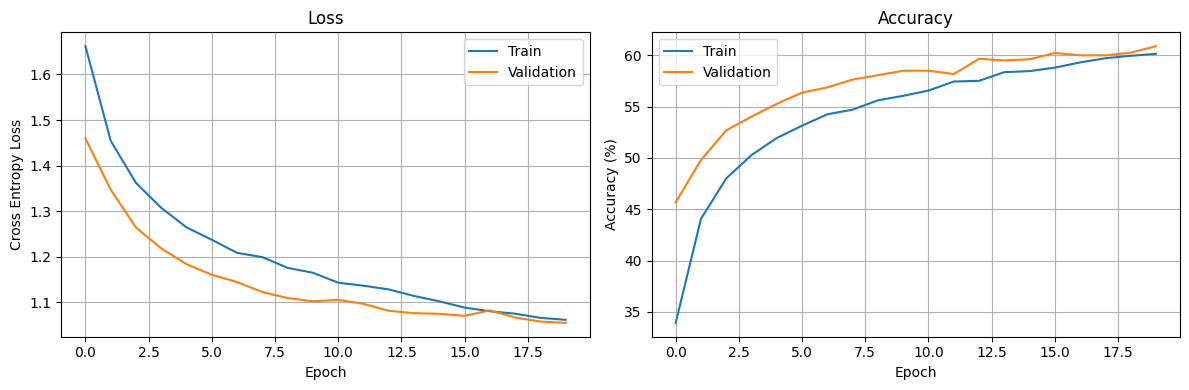

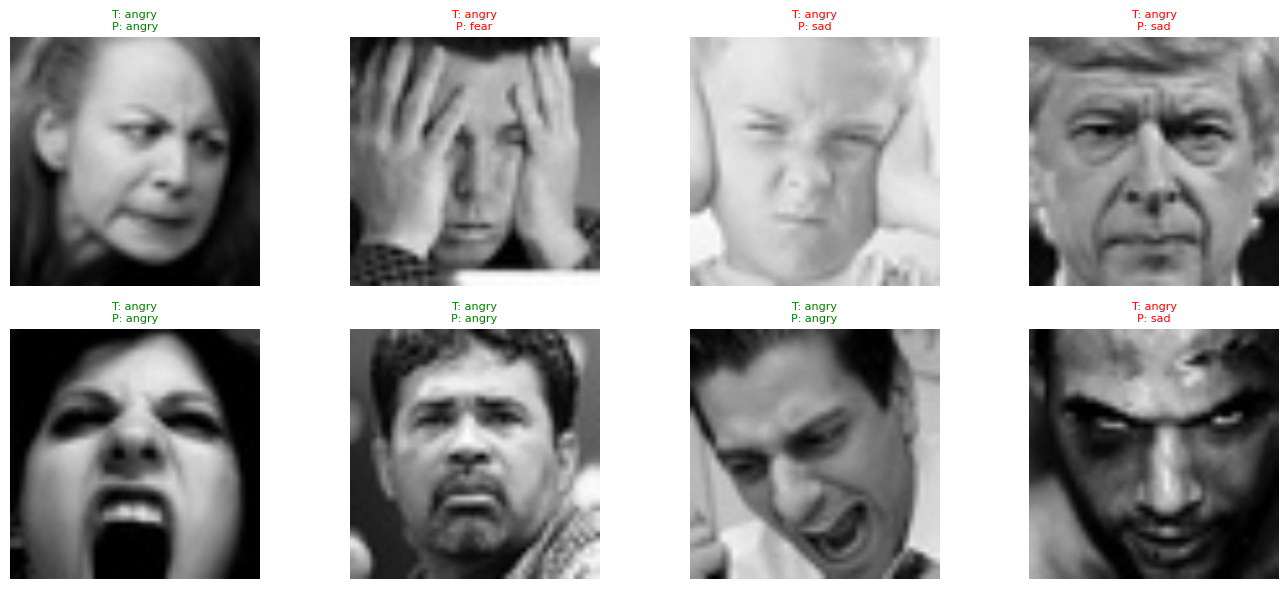


-- Confusion Matrix & Per-Class Accuracy --


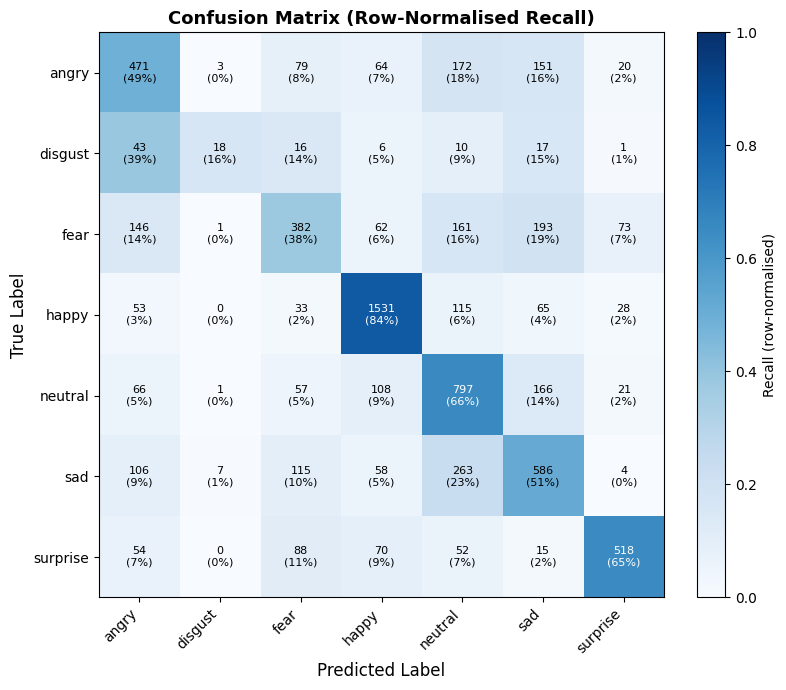

Confusion matrix saved: confusion_matrix.png


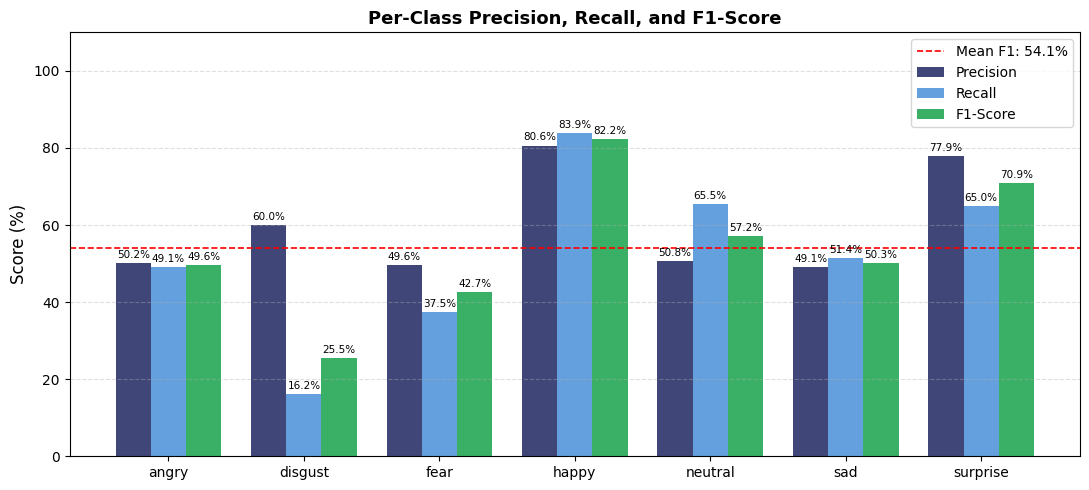

Per-class accuracy saved: per_class_accuracy.png

-- Per-Class Results --
Class         Precision     Recall   F1-Score    Support
--------------------------------------------------------
angry             50.2%      49.1%      49.6%        960
disgust           60.0%      16.2%      25.5%        111
fear              49.6%      37.5%      42.7%       1018
happy             80.6%      83.9%      82.2%       1825
neutral           50.8%      65.5%      57.2%       1216
sad               49.1%      51.4%      50.3%       1139
surprise          77.9%      65.0%      70.9%        797
--------------------------------------------------------
Overall Acc       60.9%
Mean F1           54.1%

-- Grad-CAM Feature Importance --


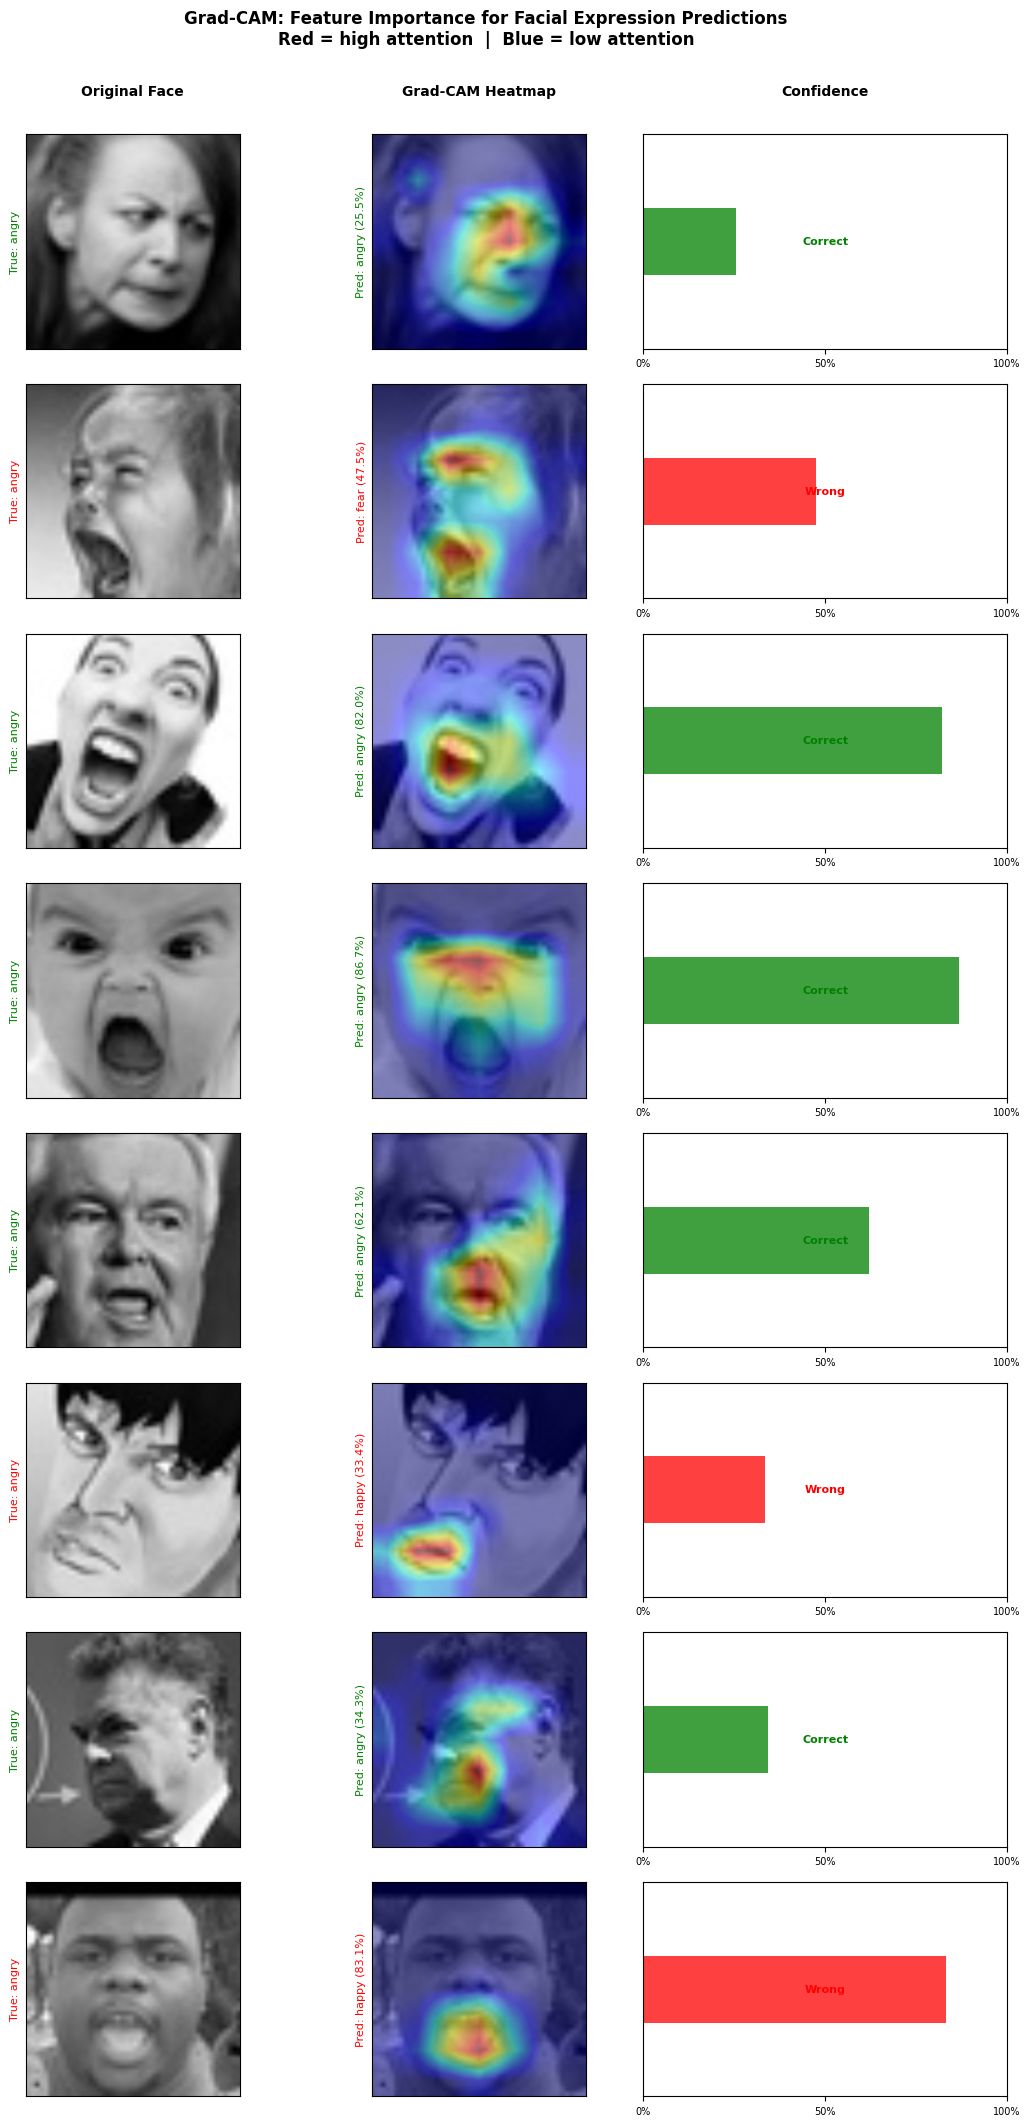

Grad-CAM saved: gradcam_results.png


In [14]:
#@title Main Function
def main():
    global EXPRESSION_LABELS

    print(f"Device: {DEVICE}")

    # Load data
    train_loader, val_loader, test_loader, EXPRESSION_LABELS = get_dataloaders()

    print("\nClass label mapping:")
    for idx, name in enumerate(EXPRESSION_LABELS):
        print(f"  {idx}: {name}")

    # Sanity check labels
    images, labels = next(iter(train_loader))
    print("\nSample labels:")
    print(labels[:10].tolist())
    print([EXPRESSION_LABELS[i] for i in labels[:10].tolist()])

    # Model
    model_efficientnet = EfficientNetB0FER(
        num_classes=CONFIG["num_classes"],
        freeze_backbone=True,
    ).to(DEVICE)

    print(f"\nModel parameters: {count_parameters(model_efficientnet):,}")

    # Train
    print("\n-- Training --")
    history = train(
        model_efficientnet,
        train_loader,
        val_loader,
        CONFIG["epochs"],
    )

    # Load best model
    model_efficientnet.load_state_dict(
        torch.load("best_model.pth", map_location=DEVICE)
    )

    # Final evaluation
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc = evaluate(model_efficientnet, test_loader, criterion)

    print("\n-- Test Results --")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc*100:.2f}%")

    # Plot curves
    plot_training_curves(history)

    # Show predictions
    predict_batch(model_efficientnet, test_loader, EXPRESSION_LABELS)

    # Confusion matrix and per-class accuracy
    print("\n-- Confusion Matrix & Per-Class Accuracy --")
    plot_confusion_matrix(model_efficientnet, test_loader, EXPRESSION_LABELS)

    # Grad-CAM — visualise feature importance on 8 test samples
    print("\n-- Grad-CAM Feature Importance --")
    run_gradcam(model_efficientnet, test_loader, EXPRESSION_LABELS, n=8)


if __name__ == "__main__":
    main()